In [20]:
import pandas as pd
import numpy as np
from pathlib import Path

##  Step 1: Imports and data path

In [21]:
DATA_DIR = Path("../../../data/raw/Yashaswi/HourlyAQI/2024/")

## Step 2: Correct reader for YOUR NAPS files

In [31]:
def read_naps_csv(path):
    df = pd.read_csv(
        path,
        skiprows=7,
        sep=","
    )

    # Clean bilingual column names
    df.columns = [c.split("//")[0].strip() for c in df.columns]

    # Normalize names we will use downstream
    df = df.rename(columns={
        "Province/Territory": "Province"
    })

    return df


In [32]:

df_test = read_naps_csv(DATA_DIR / "SO2_2024.csv")
print(df_test.columns)
print(df_test.head())


Index(['Pollutant', 'NAPS ID', 'City', 'Province', 'Latitude', 'Longitude',
       'Date', 'H01', 'H02', 'H03', 'H04', 'H05', 'H06', 'H07', 'H08', 'H09',
       'H10', 'H11', 'H12', 'H13', 'H14', 'H15', 'H16', 'H17', 'H18', 'H19',
       'H20', 'H21', 'H22', 'H23', 'H24'],
      dtype='str')
  Pollutant  NAPS ID        City Province  Latitude  Longitude        Date  \
0       SO2    10102  St. John's       NL  47.56038  -52.71147  2024-01-01   
1       SO2    10102  St. John's       NL  47.56038  -52.71147  2024-01-02   
2       SO2    10102  St. John's       NL  47.56038  -52.71147  2024-01-03   
3       SO2    10102  St. John's       NL  47.56038  -52.71147  2024-01-04   
4       SO2    10102  St. John's       NL  47.56038  -52.71147  2024-01-05   

   H01  H02  H03  ...  H15  H16  H17  H18  H19  H20  H21  H22  H23  H24  
0  0.0  0.0  0.0  ...  0.0  0.1  0.1  0.1  0.1  0.1  0.1  0.2  0.1  0.2  
1  0.1  0.0  0.0  ...  0.1  0.0  0.1  0.1  0.1  0.1  0.2  0.1  0.1  0.1  
2  0.1  0.0  0.0

##  Step 3: Reshape hourly → long format

In [33]:
def reshape_hourly(df):
    # Normalize pollutant naming
    df["Pollutant"] = (
        df["Pollutant"]
        .replace({"PM25": "PM2.5"})
        .astype(str)
    )

    # Ignore NO and NOX
    if df["Pollutant"].iloc[0] in {"NO", "NOX"}:
        return None

    hour_cols = [c for c in df.columns if c.startswith("H")]

    df_long = df.melt(
        id_vars=[
            "Pollutant",
            "NAPS ID",
            "City",
            "Province",
            "Latitude",
            "Longitude",
            "Date",
        ],
        value_vars=hour_cols,
        var_name="Hour",
        value_name="Concentration",
    )

    df_long["Hour"] = df_long["Hour"].str.replace("H", "").astype(int) - 1
    df_long["Datetime"] = (
        pd.to_datetime(df_long["Date"])
        + pd.to_timedelta(df_long["Hour"], unit="h")
    )

    df_long.loc[df_long["Concentration"] == -999, "Concentration"] = np.nan

    return df_long

## Step 4: Unit conversion (O₃ only)

In [34]:
def apply_units(df):
    if df["Pollutant"].iloc[0] == "O3":
        # O₃ is in ppb → convert to ppm for EPA AQI
        df["Concentration"] = df["Concentration"] / 1000.0
    return df

## Step 5: Daily AQI concentration metric

In [35]:
def daily_metric(df):
    pol = df["Pollutant"].iloc[0]
    g = df.groupby(["NAPS ID", df["Datetime"].dt.date])

    if pol in {"O3", "CO"}:
        # Daily max 8‑hour rolling average
        return (
            g.apply(
                lambda x: x.set_index("Datetime")["Concentration"]
                .rolling(8, min_periods=6)
                .mean()
                .max()
            )
            .rename("C")
            .reset_index()
        )

    if pol in {"NO2", "SO2"}:
        # Daily max 1‑hour
        return g["Concentration"].max().reset_index(name="C")

    if pol in {"PM10", "PM2.5"}:
        # 24‑hour mean
        return g["Concentration"].mean().reset_index(name="C")

## Step 6: EPA AQI breakpoints

In [36]:
AQI_BREAKPOINTS = {
    "O3": [
        (0.000, 0.054, 0, 50),
        (0.055, 0.070, 51, 100),
        (0.071, 0.085, 101, 150),
        (0.086, 0.105, 151, 200),
        (0.106, 0.200, 201, 300),
    ],
    "PM2.5": [
        (0.0, 9.0, 0, 50),
        (9.1, 35.4, 51, 100),
        (35.5, 55.4, 101, 150),
        (55.5, 125.4, 151, 200),
        (125.5, 225.4, 201, 300),
        (225.5, 325.4, 301, 500),
    ],
    "PM10": [
        (0, 54, 0, 50),
        (55, 154, 51, 100),
        (155, 254, 101, 150),
        (255, 354, 151, 200),
        (355, 424, 201, 300),
        (425, 604, 301, 500),
    ],
    "CO": [
        (0.0, 4.4, 0, 50),
        (4.5, 9.4, 51, 100),
        (9.5, 12.4, 101, 150),
        (12.5, 15.4, 151, 200),
        (15.5, 30.4, 201, 300),
    ],
    "NO2": [
        (0, 53, 0, 50),
        (54, 100, 51, 100),
        (101, 360, 101, 150),
        (361, 649, 151, 200),
        (650, 1249, 201, 300),
    ],
    "SO2": [
        (0, 35, 0, 50),
        (36, 75, 51, 100),
        (76, 185, 101, 150),
        (186, 304, 151, 200),
        (305, 604, 201, 300),
    ],
}

## Step 7: AQI calculation

In [37]:
def compute_aqi(C, pollutant):
    if pd.isna(C):
        return np.nan

    for c_lo, c_hi, aqi_lo, aqi_hi in AQI_BREAKPOINTS[pollutant]:
        if c_lo <= C <= c_hi:
            return round(
                (aqi_hi - aqi_lo)
                / (c_hi - c_lo)
                * (C - c_lo)
                + aqi_lo
            )

    return np.nan

## Quick test 

In [38]:
print(compute_aqi(0.060, "O3"))     # Should be Moderate (~67)
print(compute_aqi(35.0, "PM2.5"))  # Should be ~100
print(compute_aqi(8.0, "CO"))      # Should be Moderate

67
99
86


##  Step 8: Run AQI for all 2024 files 🎯

In [39]:
FILES = [
    "O3_2024.csv",
    "NO2_2024.csv",
    "CO_2024.csv",
    "PM25_2024.csv",
    "PM10_2024.csv",
    "SO2_2024.csv",
]

daily_results = []

for fname in FILES:
    print(f"Processing {fname}")

    df_raw = read_naps_csv(DATA_DIR / fname)
    df_long = reshape_hourly(df_raw)

    if df_long is None:
        continue

    df_long = apply_units(df_long)
    daily = daily_metric(df_long)

    pollutant = df_long["Pollutant"].iloc[0]
    daily["Pollutant"] = pollutant
    daily["AQI"] = daily["C"].apply(lambda x: compute_aqi(x, pollutant))

    daily_results.append(daily)

aqi_daily = pd.concat(daily_results, ignore_index=True)

Processing O3_2024.csv
Processing NO2_2024.csv
Processing CO_2024.csv
Processing PM25_2024.csv
Processing PM10_2024.csv
Processing SO2_2024.csv


In [40]:
aqi_daily.head()

,NAPS ID,Datetime,C,Pollutant,AQI
0,10102,2024-01-01,0.032625,O3,30.0
1,10102,2024-01-02,0.034375,O3,32.0
2,10102,2024-01-03,0.034333,O3,32.0
3,10102,2024-01-04,0.032500,O3,30.0
4,10102,2024-01-05,0.031875,O3,30.0


In [41]:
aqi_daily.shape

(350628, 5)

In [42]:
aqi_daily["AQI"].describe()

count    335353.000000
mean         19.571150
std          18.069716
min           0.000000
25%           5.000000
50%          16.000000
75%          30.000000
max         488.000000
Name: AQI, dtype: float64

In [43]:
aqi_daily["Pollutant"].value_counts()

Pollutant
O3       87108
PM2.5    86742
NO2      73932
SO2      51240
PM10     30744
CO       20862
Name: count, dtype: int64

In [45]:

daily_official_aqi = (
    aqi_daily
    .sort_values("AQI", ascending=False)
    .groupby(["NAPS ID", "Datetime"], as_index=False)
    .first()
)
daily_official_aqi.head()

,NAPS ID,Datetime,C,Pollutant,AQI
0,10102,2024-01-01,0.032625,O3,30.0
1,10102,2024-01-02,0.034375,O3,32.0
2,10102,2024-01-03,0.034333,O3,32.0
3,10102,2024-01-04,0.032500,O3,30.0
4,10102,2024-01-05,0.031875,O3,30.0


# Vizualization
## Step A — Prepare data for plotting

In [46]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Make sure Datetime is datetime
aqi_daily = aqi_daily.copy()
aqi_daily["Datetime"] = pd.to_datetime(aqi_daily["Datetime"])

# Aggregate: daily mean AQI per pollutant (across stations)
daily_pollutant = (
    aqi_daily
    .groupby(["Datetime", "Pollutant"], as_index=False)
    .agg(mean_AQI=("AQI", "mean"))
)

## Step B — Multi‑panel time‑series plots (one per pollutant)

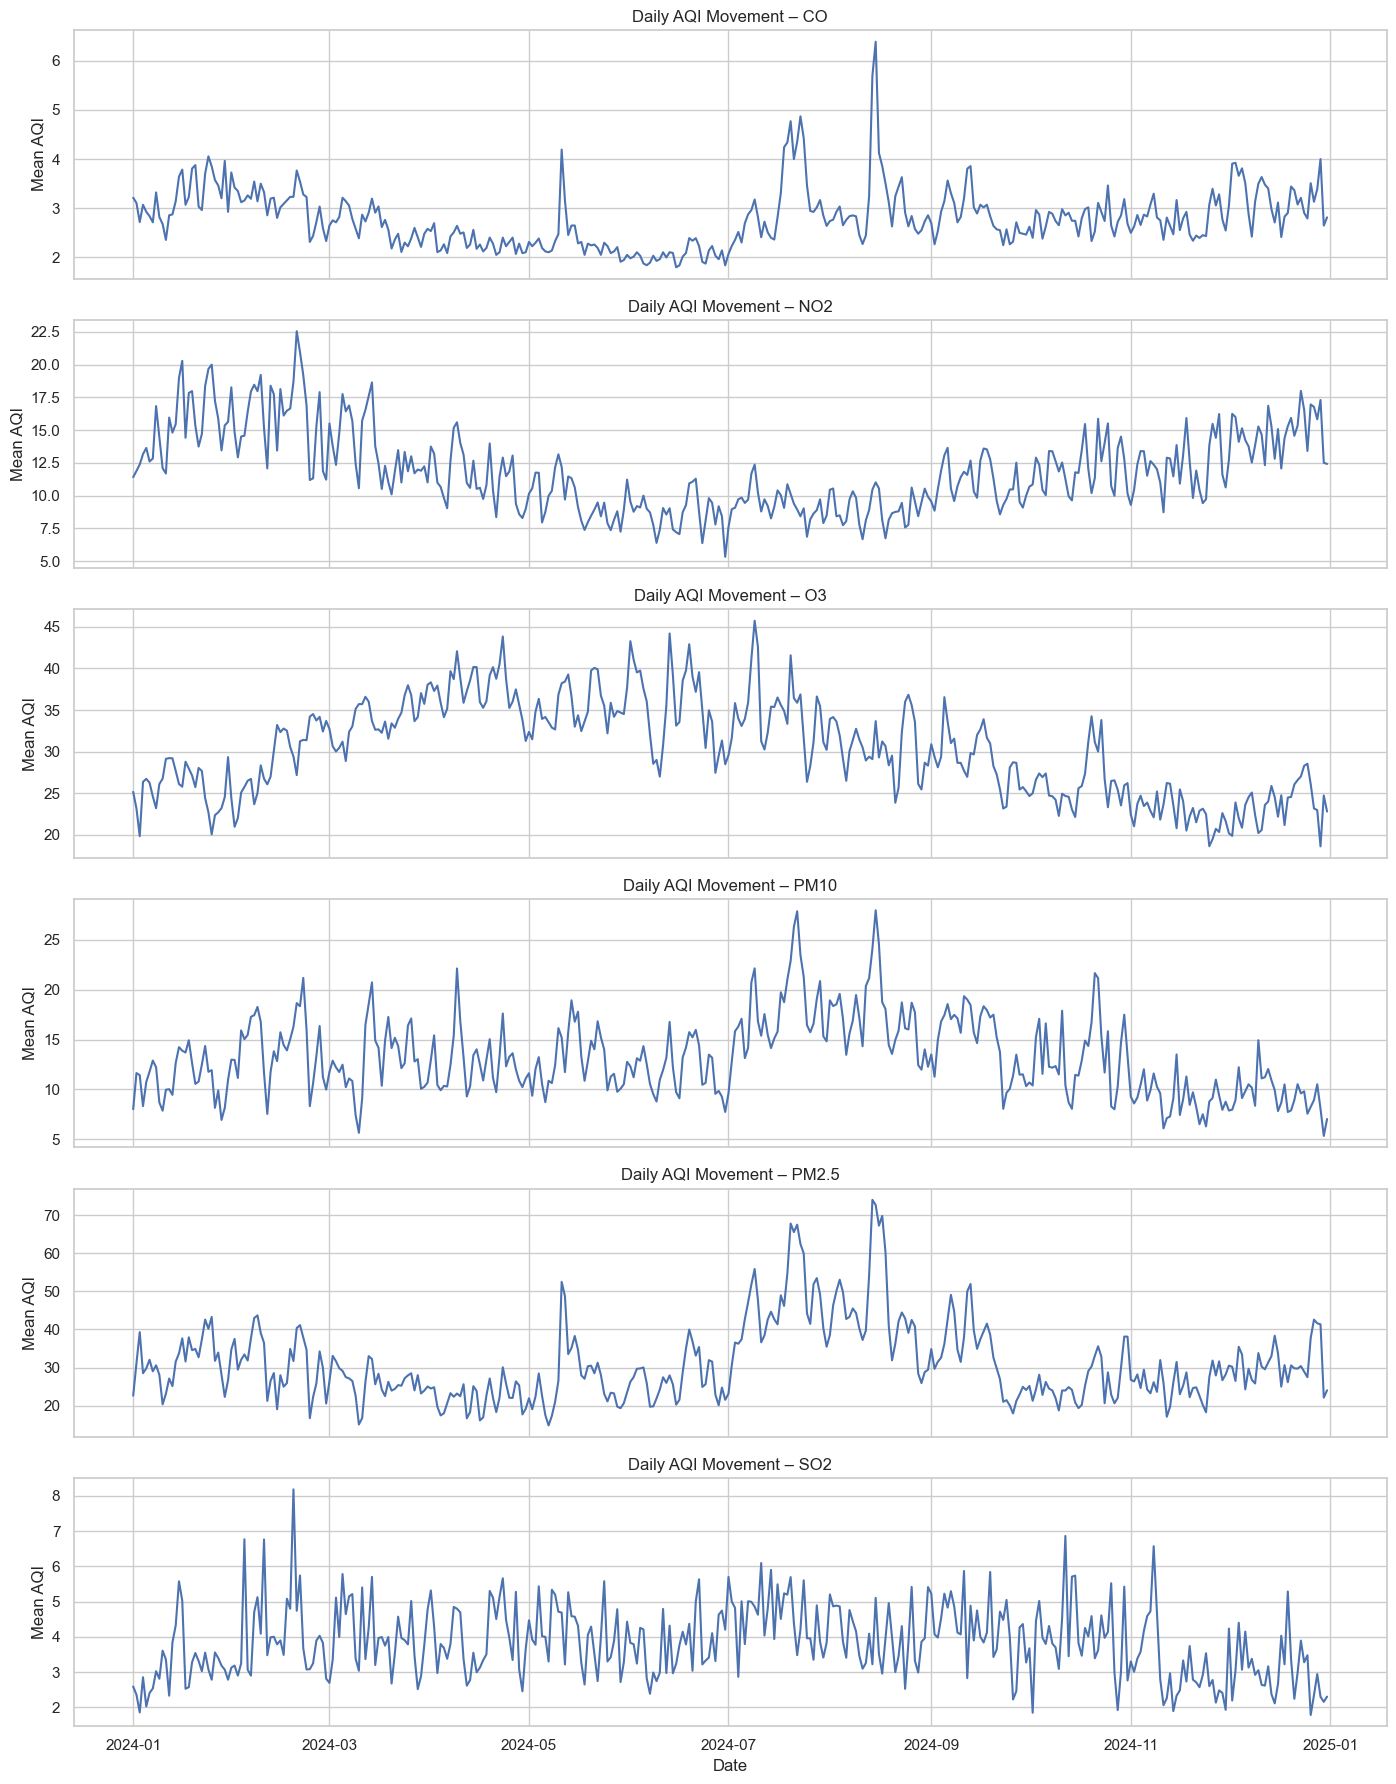

In [47]:
# Plot style
sns.set_theme(style="whitegrid")

pollutants = sorted(daily_pollutant["Pollutant"].unique())
n_pollutants = len(pollutants)

fig, axes = plt.subplots(
    nrows=n_pollutants,
    ncols=1,
    figsize=(14, 3 * n_pollutants),
    sharex=True
)

if n_pollutants == 1:
    axes = [axes]

for ax, pol in zip(axes, pollutants):
    subset = daily_pollutant[daily_pollutant["Pollutant"] == pol]

    sns.lineplot(
        data=subset,
        x="Datetime",
        y="mean_AQI",
        ax=ax
    )

    ax.set_title(f"Daily AQI Movement – {pol}")
    ax.set_ylabel("Mean AQI")
    ax.set_xlabel("Date")

plt.tight_layout()
plt.show()

## Add AQI category and color to your daily data
 - Define category + color mapping

In [49]:
def aqi_category_color(aqi):
    if pd.isna(aqi):
        return pd.Series([np.nan, np.nan])

    if aqi <= 50:
        return pd.Series(["Good", "green"])
    elif aqi <= 100:
        return pd.Series(["Moderate", "yellow"])
    elif aqi <= 150:
        return pd.Series(["Unhealthy for Sensitive Groups", "orange"])
    elif aqi <= 200:
        return pd.Series(["Unhealthy", "red"])
    elif aqi <= 300:
        return pd.Series(["Very Unhealthy", "purple"])
    else:
        return pd.Series(["Hazardous", "maroon"])

##  Apply it to your dataset

In [51]:
aqi_daily[["AQI_Category", "AQI_Color"]] = (
    aqi_daily["AQI"].apply(aqi_category_color)
)

## 3️⃣ Color‑coded daily time‑series visualizations (one chart per pollutant)
We’ll build on your earlier visualization, but now:

Each pollutant has its own subplot
Line color reflects EPA AQI color category
Interpretation aligns exactly with the reporting standard

### Prepare daily mean AQI per pollutant (for cleaner plots)

In [52]:
daily_pollutant = (
    aqi_daily
    .groupby(["Datetime", "Pollutant"], as_index=False)
    .agg(mean_AQI=("AQI", "mean"))
)

daily_pollutant[["AQI_Category", "AQI_Color"]] = (
    daily_pollutant["mean_AQI"].apply(aqi_category_color)
)

##  EPA‑colored multi‑panel visualization

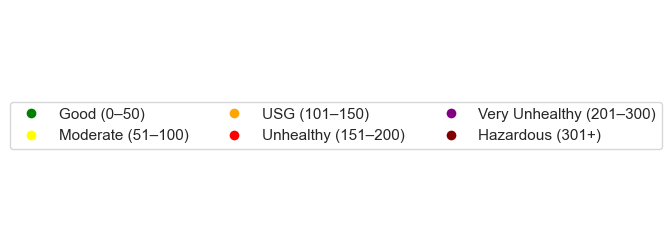

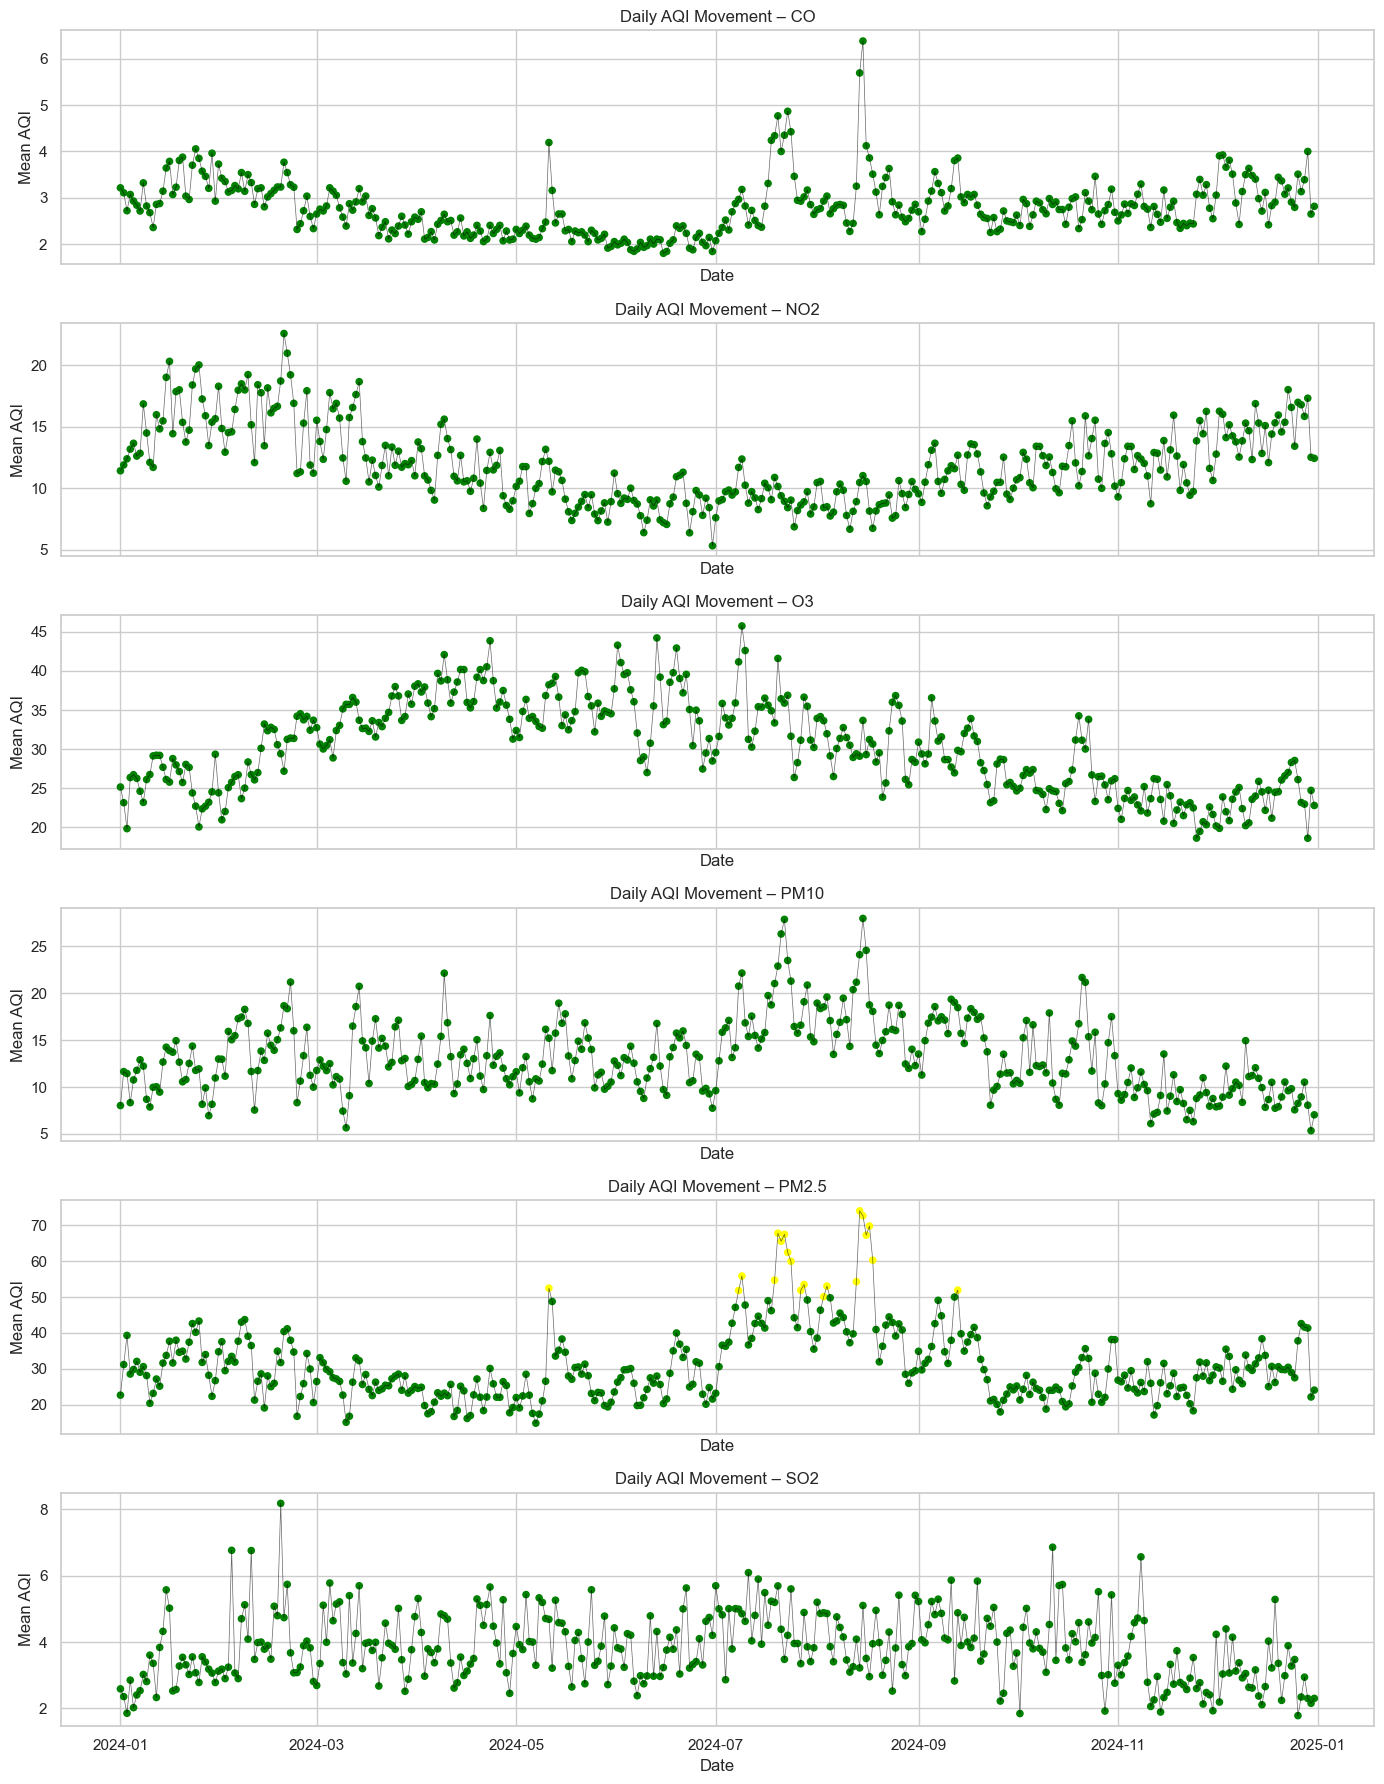

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Good (0–50)', markerfacecolor='green', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Moderate (51–100)', markerfacecolor='yellow', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='USG (101–150)', markerfacecolor='orange', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Unhealthy (151–200)', markerfacecolor='red', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Very Unhealthy (201–300)', markerfacecolor='purple', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Hazardous (301+)', markerfacecolor='maroon', markersize=8),
]

plt.figure(figsize=(8, 3))
plt.legend(handles=legend_elements, loc='center', ncol=3)
plt.axis('off')
plt.show()

sns.set_theme(style="whitegrid")

pollutants = sorted(daily_pollutant["Pollutant"].unique())
n_pollutants = len(pollutants)

fig, axes = plt.subplots(
    nrows=n_pollutants,
    ncols=1,
    figsize=(14, 3 * n_pollutants),
    sharex=True
)

if n_pollutants == 1:
    axes = [axes]

for ax, pol in zip(axes, pollutants):
    sub = daily_pollutant[daily_pollutant["Pollutant"] == pol]

    ax.scatter(
        sub["Datetime"],
        sub["mean_AQI"],
        c=sub["AQI_Color"],
        s=20
    )

    ax.plot(
        sub["Datetime"],
        sub["mean_AQI"],
        color="black",
        linewidth=0.5,
        alpha=0.6
    )

    ax.set_title(f"Daily AQI Movement – {pol}")
    ax.set_ylabel("Mean AQI")
    ax.set_xlabel("Date")

plt.tight_layout()
plt.show()

 ## Step 1: Load the station lookup CSV

In [63]:
import pandas as pd

station_lookup = pd.read_csv( "../../../data/raw/Yashaswi/HourlyAQI/StationsNAPS.csv")  # <-- update path

station_lookup.head()

,NAPS_ID,Station_Name,Status,Location_Address,City,Province/Territory,Postal_Code,Timezone_UTC,Latitude,Longitude,Elevation_m,Start_Date,End_Date
0,10101,DUCKWORTH & ORDINANCE,0.0,DUCKWORTH & ORDINANCE,ST. JOHN'S,NEWFOUNDLAND AND LABRADOR,A1C 1E4,-3.5,47.568060,-52.702220,7.0,2/7/1975,7/26/1988
1,10102,WATER STREET POST OFFICE,1.0,354 WATER STREET,ST. JOHN'S,NEWFOUNDLAND AND LABRADOR,A1C 1C4,-3.5,47.560380,-52.711470,7.0,7/31/1988,NaN
2,10301,CREDIT UNION,0.0,BROOK STREET,CORNER BROOK,NEWFOUNDLAND AND LABRADOR,A2H 2T7,-3.5,48.949479,-57.945387,5.0,6/30/2001,5/22/2014
3,10401,MOUNT PEARL,1.0,OLD PLACENTIA ROAD,MOUNT PEARL,NEWFOUNDLAND AND LABRADOR,A1N 4P4,-3.5,47.505130,-52.794760,135.0,5/4/2002,NaN
4,10501,ABITIBI SITE,1.0,SCOTT AVENUE,GRAND FALLS - WINDSOR,NEWFOUNDLAND AND LABRADOR,A2A 2K1,-3.5,48.926960,-55.659660,62.0,5/17/2004,NaN


## Step 3: Align column names for merging

In [66]:

station_lookup = (
    station_lookup[["NAPS_ID","City", "Province/Territory"]]
    .drop_duplicates()
)


station_lookup = station_lookup.rename(
    columns={"NAPS_ID": "NAPS ID"}
)


## Step 4: Merge province/territory into aqi_daily

In [99]:


# Ensure same type for join key
aqi_daily["NAPS ID"] = aqi_daily["NAPS ID"].astype(str)
station_lookup["NAPS ID"] = station_lookup["NAPS ID"].astype(str)

aqi_daily = aqi_daily.merge(
    station_lookup,
    on="NAPS ID",
    how="left"
)
aqi_daily = (
    aqi_daily
    .drop(columns=["City_x", "Province/Territory_x"])
    .rename(columns={
        "City_y": "City",
        "Province/Territory_y": "Province/Territory"
    })
)
aqi_daily.columns[aqi_daily.columns.duplicated()]
print(aqi_daily.columns.tolist())



['NAPS ID', 'Datetime', 'C', 'Pollutant', 'AQI', 'AQI_Category', 'AQI_Color', 'Month', 'City', 'Province/Territory']


# EXPORT AQI FILE ( merged with province list)

In [100]:

aqi_daily.to_csv(
    "aqi_daily_2024.csv",
    index=False
)


## 0️⃣ Imports & datetime safety

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure Datetime is datetime
aqi_daily = aqi_daily.copy()
aqi_daily["Datetime"] = pd.to_datetime(aqi_daily["Datetime"])

## 1️⃣ Daily AQI movement by pollutant
 - One subplot per pollutant, EPA color‑coded

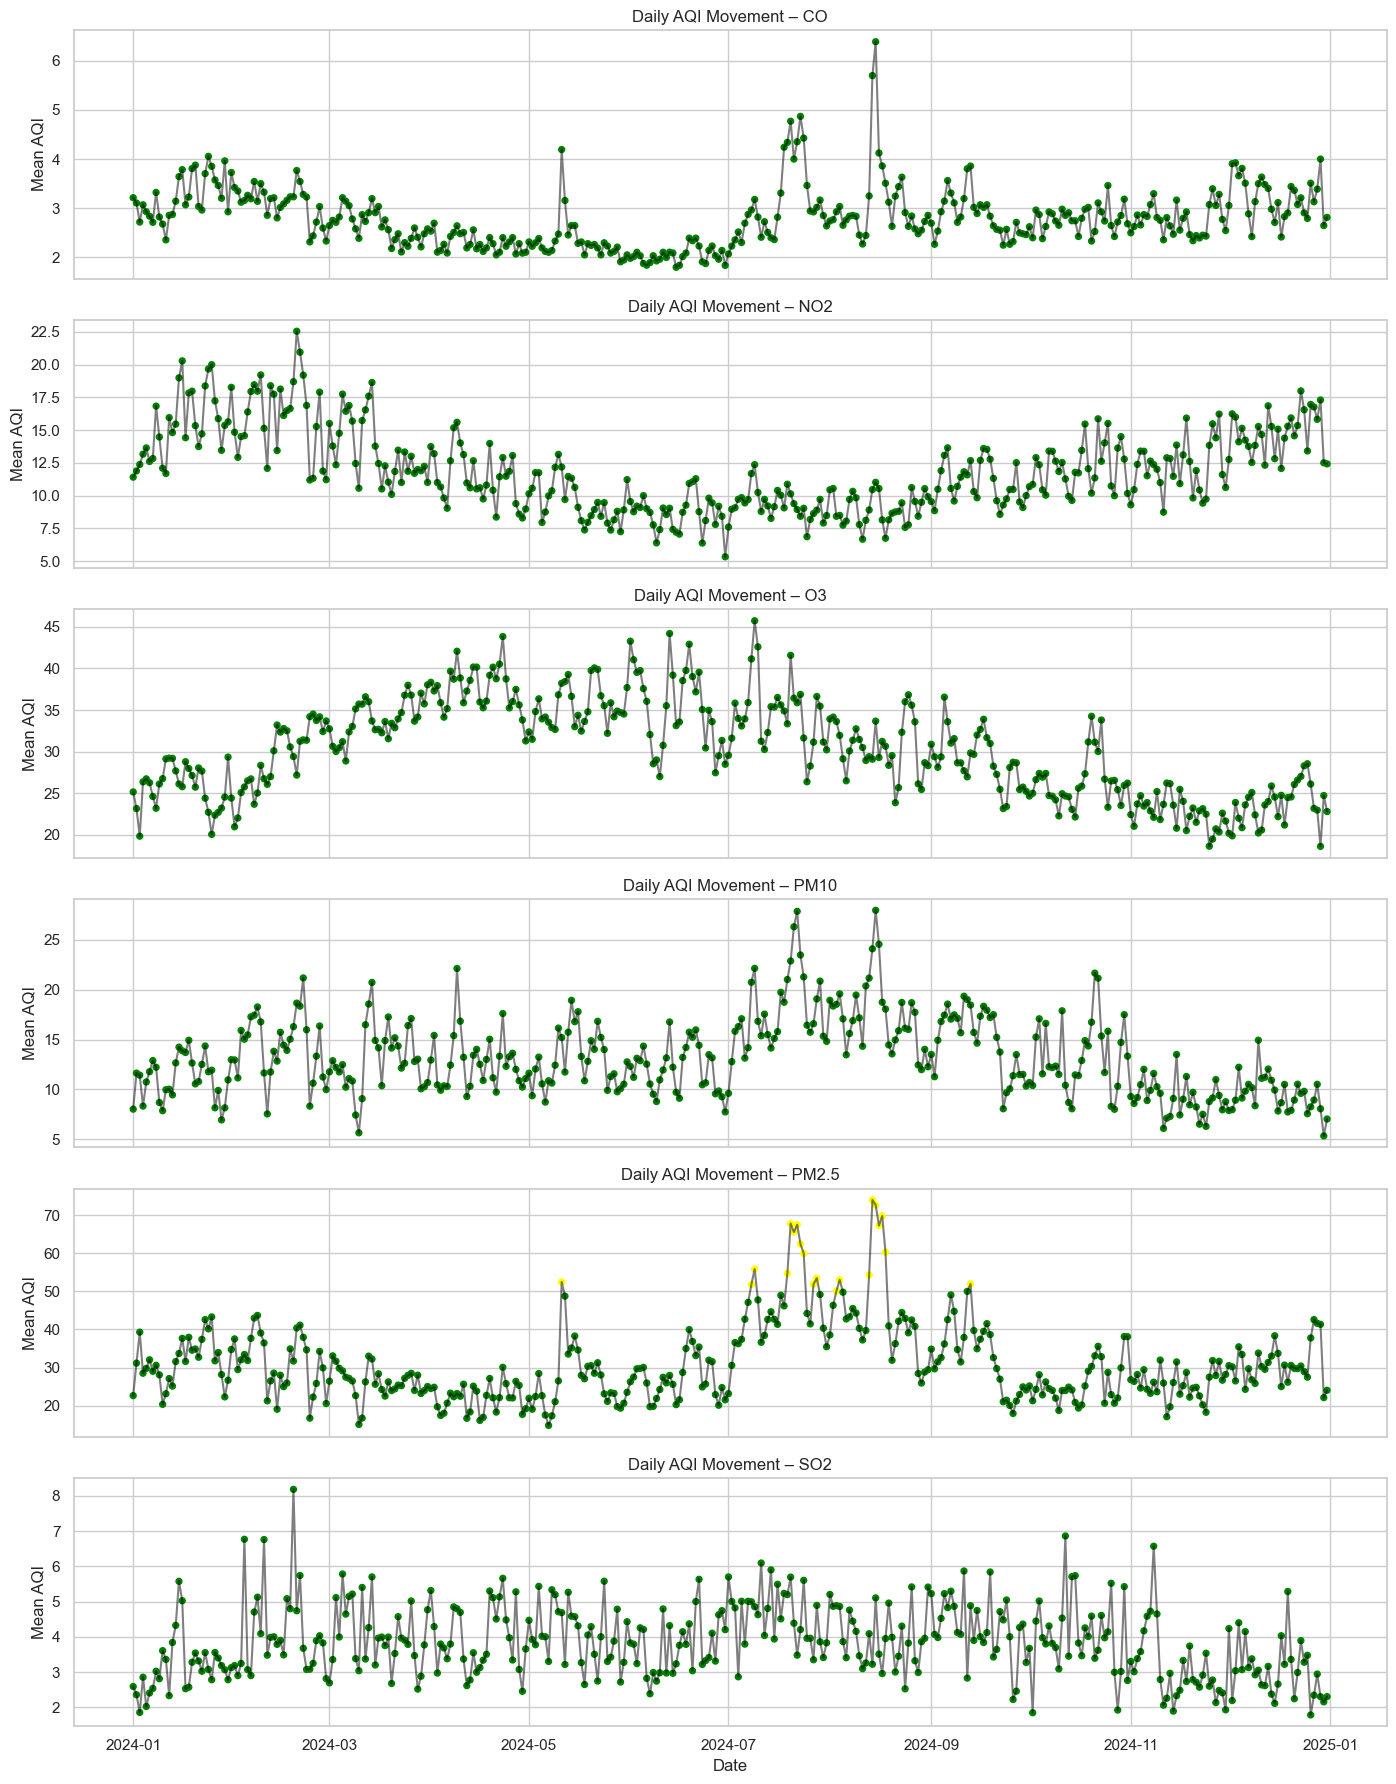

In [75]:
# Aggregate: daily mean AQI per pollutant (across stations)
daily_pollutant = (
    aqi_daily
    .groupby(["Datetime", "Pollutant"], as_index=False)
    .agg(mean_AQI=("AQI", "mean"))
)

# Attach AQI category/color to aggregated values
def aqi_cat_color(aqi):
    if pd.isna(aqi):
        return np.nan, np.nan
    if aqi <= 50:
        return "Good", "green"
    elif aqi <= 100:
        return "Moderate", "yellow"
    elif aqi <= 150:
        return "Unhealthy for Sensitive Groups", "orange"
    elif aqi <= 200:
        return "Unhealthy", "red"
    elif aqi <= 300:
        return "Very Unhealthy", "purple"
    else:
        return "Hazardous", "maroon"

daily_pollutant[["AQI_Category", "AQI_Color"]] = (
    daily_pollutant["mean_AQI"]
    .apply(lambda x: pd.Series(aqi_cat_color(x)))
)

sns.set_theme(style="whitegrid")

pollutants = sorted(daily_pollutant["Pollutant"].unique())
fig, axes = plt.subplots(len(pollutants), 1, figsize=(14, 3 * len(pollutants)), sharex=True)

if len(pollutants) == 1:
    axes = [axes]

for ax, pol in zip(axes, pollutants):
    sub = daily_pollutant[daily_pollutant["Pollutant"] == pol]

    ax.scatter(
        sub["Datetime"],
        sub["mean_AQI"],
        c=sub["AQI_Color"],
        s=18
    )
    ax.plot(sub["Datetime"], sub["mean_AQI"], color="black", alpha=0.5)

    ax.set_title(f"Daily AQI Movement – {pol}")
    ax.set_ylabel("Mean AQI")

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

## 2️⃣ Daily AQI comparison by Province / Territory

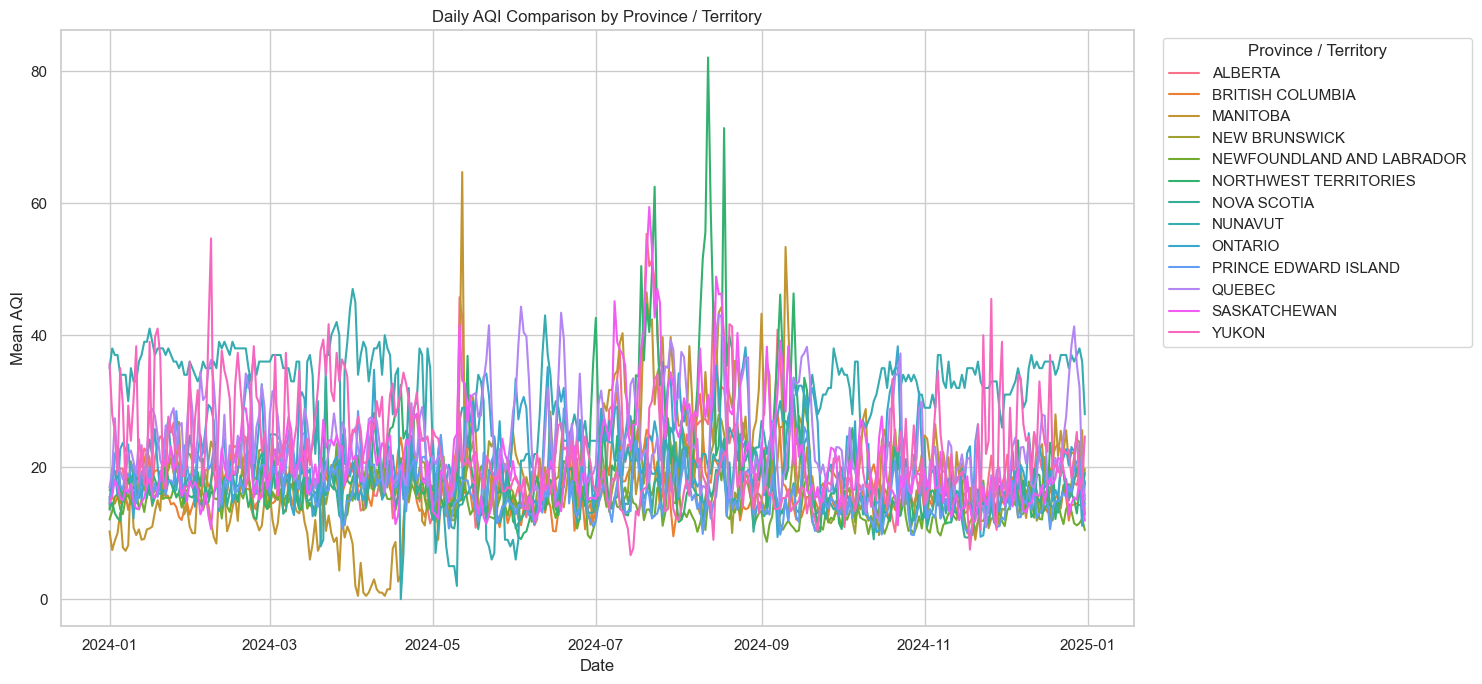

In [77]:
daily_province = (
    aqi_daily
    .groupby(["Datetime", "Province/Territory"], as_index=False)
    .agg(mean_AQI=("AQI", "mean"))
)

plt.figure(figsize=(15, 7))

sns.lineplot(
    data=daily_province,
    x="Datetime",
    y="mean_AQI",
    hue="Province/Territory"
)

plt.title("Daily AQI Comparison by Province / Territory")
plt.xlabel("Date")
plt.ylabel("Mean AQI")
plt.legend(
    title="Province / Territory",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

## 3️⃣ Monthly AQI distribution by Province / Territory (boxplots)

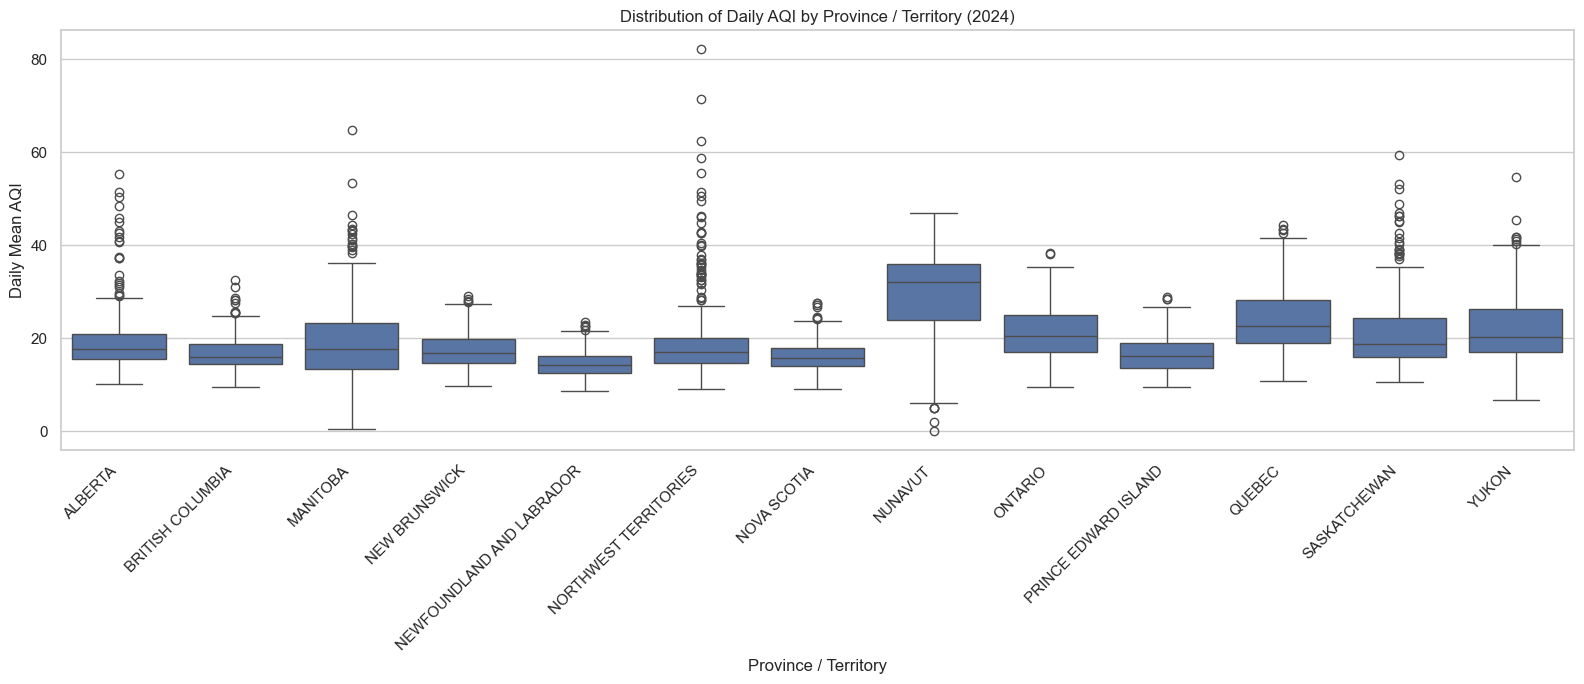

In [79]:
daily_province["Month"] = daily_province["Datetime"].dt.to_period("M").astype(str)

plt.figure(figsize=(16, 7))
sns.boxplot(
    data=daily_province,
    x="Province/Territory",
    y="mean_AQI"
)

plt.title("Distribution of Daily AQI by Province / Territory (2024)")
plt.xlabel("Province / Territory")
plt.ylabel("Daily Mean AQI")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 4️⃣ Heatmap: AQI over time by Province / Territory

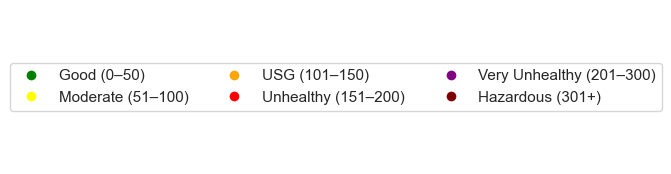

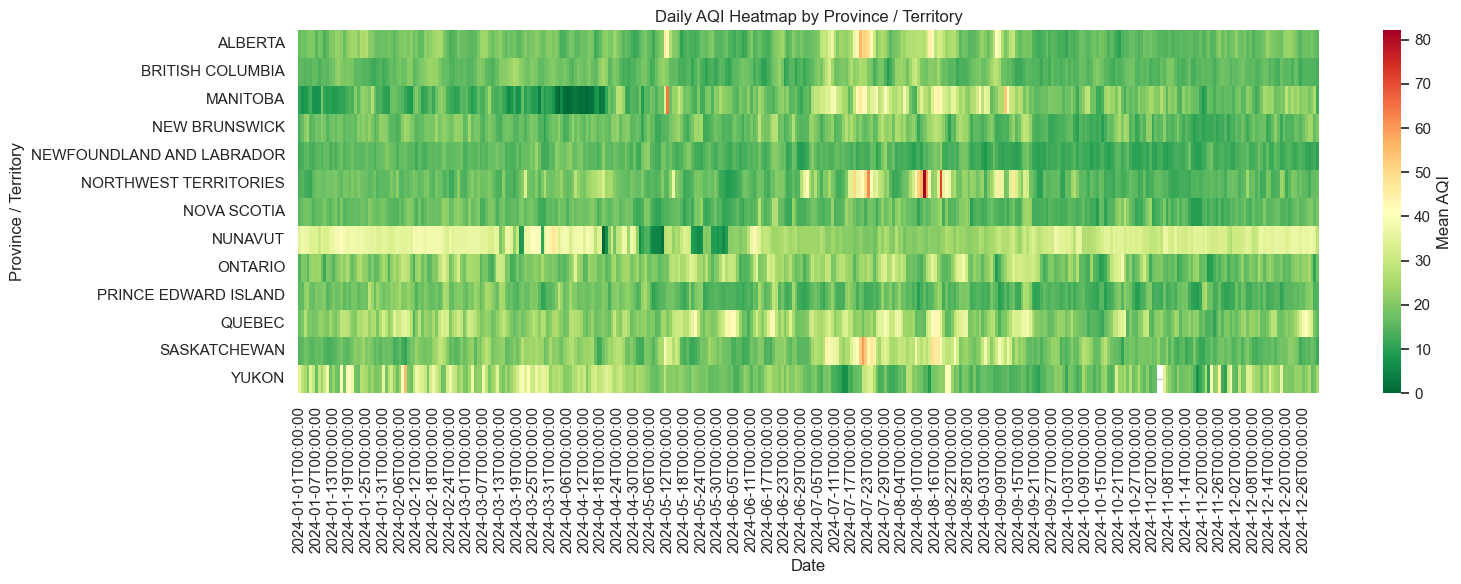

In [82]:
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Good (0–50)', markerfacecolor='green', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Moderate (51–100)', markerfacecolor='yellow', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='USG (101–150)', markerfacecolor='orange', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Unhealthy (151–200)', markerfacecolor='red', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Very Unhealthy (201–300)', markerfacecolor='purple', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Hazardous (301+)', markerfacecolor='maroon', markersize=8),
]

plt.figure(figsize=(8, 2))
plt.legend(handles=legend_elements, loc="center", ncol=3)
plt.axis("off")
plt.show()

heatmap_data = (
    daily_province
    .pivot_table(
        index="Province/Territory",
        columns="Datetime",
        values="mean_AQI"
    )
)

plt.figure(figsize=(16, 6))
sns.heatmap(
    heatmap_data,
    cmap="RdYlGn_r",
    cbar_kws={"label": "Mean AQI"}
)

plt.title("Daily AQI Heatmap by Province / Territory")
plt.xlabel("Date")
plt.ylabel("Province / Territory")
plt.tight_layout()
plt.show()


## ✅ STEP 1: Convert daily AQI → monthly AQI by Province/Territory
- We compute monthly mean AQI (one can also use median if want robustness).

In [84]:
# Ensure Datetime is datetime
aqi_daily = aqi_daily.copy()
aqi_daily["Datetime"] = pd.to_datetime(aqi_daily["Datetime"])

# Create Month column
aqi_daily["Month"] = aqi_daily["Datetime"].dt.to_period("M").astype(str)

# Monthly mean AQI by Province / Territory
monthly_province_aqi = (
    aqi_daily
    .groupby(["Month", "Province/Territory"], as_index=False)
    .agg(mean_AQI=("AQI", "mean"))
)

monthly_province_aqi.head()

,Month,Province/Territory,mean_AQI
0,2024-01,ALBERTA,19.973615
1,2024-01,BRITISH COLUMBIA,16.040846
2,2024-01,MANITOBA,13.532710
3,2024-01,NEW BRUNSWICK,18.223660
4,2024-01,NEWFOUNDLAND AND LABRADOR,15.228484


## ✅ STEP 2: Monthly AQI comparison (clear visualization)
🔹 Option A: Line plot (trend comparison)

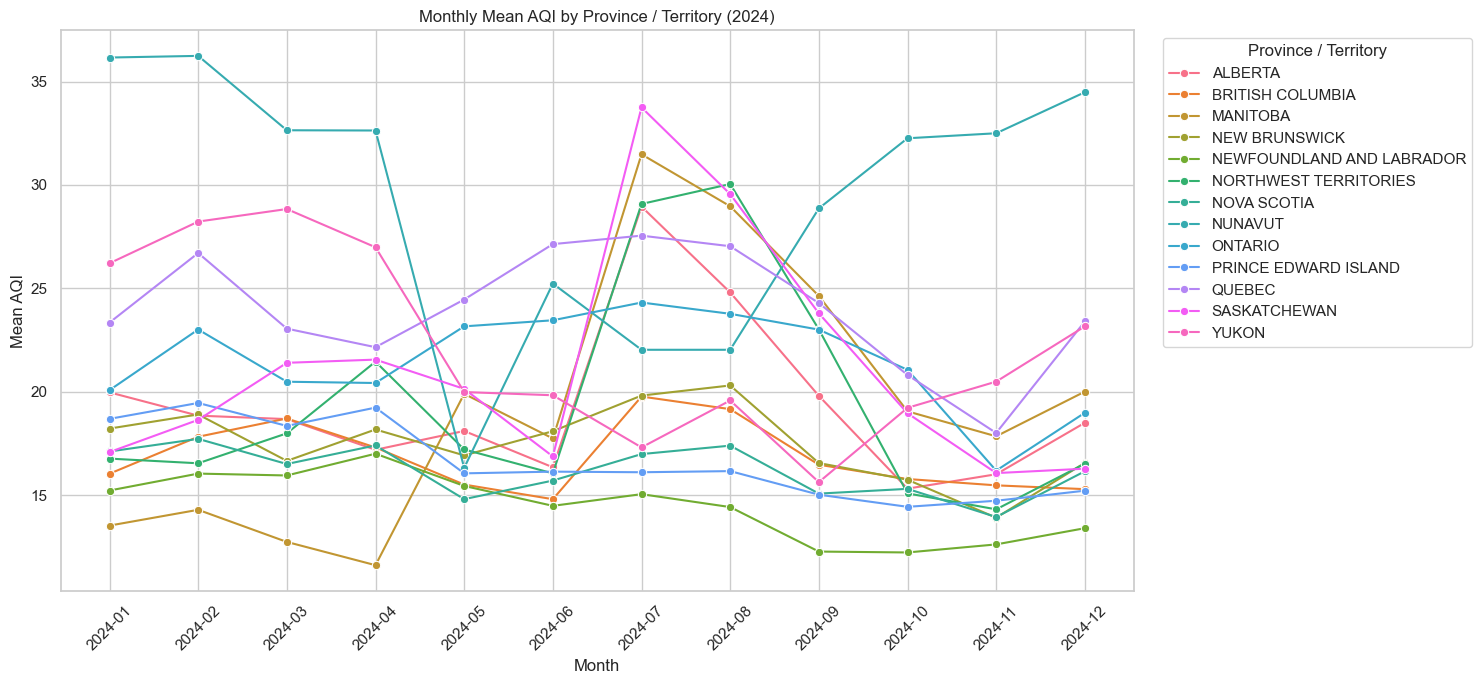

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(15, 7))

sns.lineplot(
    data=monthly_province_aqi,
    x="Month",
    y="mean_AQI",
    hue="Province/Territory",
    marker="o"
)

plt.title("Monthly Mean AQI by Province / Territory (2024)")
plt.xlabel("Month")
plt.ylabel("Mean AQI")
plt.xticks(rotation=45)
plt.legend(
    title="Province / Territory",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

## 🔹 Option B (RECOMMENDED): Monthly AQI bar chart
This makes “which province is higher” very obvious.

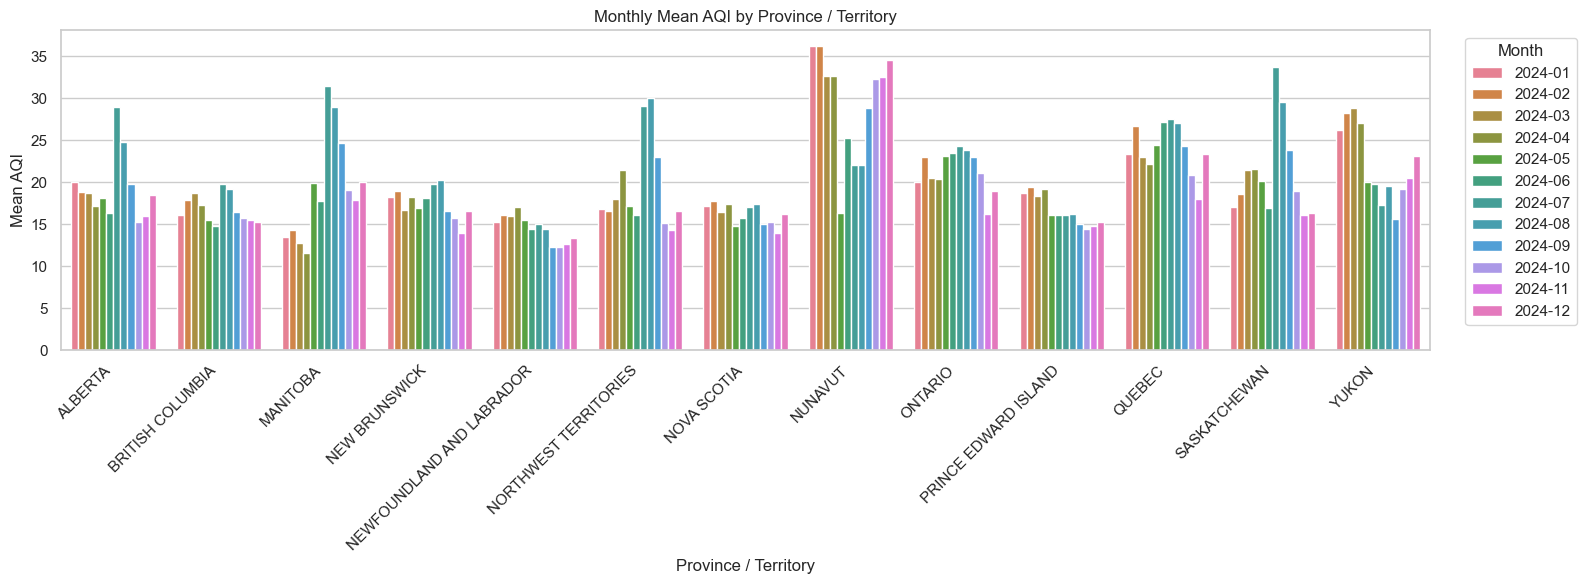

In [86]:
plt.figure(figsize=(16, 6))

sns.barplot(
    data=monthly_province_aqi,
    x="Province/Territory",
    y="mean_AQI",
    hue="Month"
)

plt.title("Monthly Mean AQI by Province / Territory")
plt.xlabel("Province / Territory")
plt.ylabel("Mean AQI")
plt.xticks(rotation=45, ha="right")
plt.legend(
    title="Month",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

## ✅ STEP 3: Identify which province has higher AQI (NUMERIC ANSWER)
✅ A. Overall (entire year)

In [87]:
province_rank = (
    aqi_daily
    .groupby("Province/Territory", as_index=False)
    .agg(
        annual_mean_AQI=("AQI", "mean"),
        max_AQI=("AQI", "max"),
        unhealthy_days=("AQI", lambda x: (x > 100).sum())
    )
    .sort_values("annual_mean_AQI", ascending=False)
)

province_rank

,Province/Territory,annual_mean_AQI,max_AQI,unhealthy_days
7,NUNAVUT,29.240437,47.0,0
10,QUEBEC,23.966686,188.0,62
12,YUKON,22.122316,113.0,1
8,ONTARIO,21.490296,127.0,23
11,SASKATCHEWAN,21.218044,422.0,121
2,MANITOBA,20.818734,196.0,34
5,NORTHWEST TERRITORIES,19.649652,484.0,56
0,ALBERTA,19.398385,426.0,775
3,NEW BRUNSWICK,17.493549,123.0,7
1,BRITISH COLUMBIA,16.847618,488.0,102


## ✅ B. Worst province per month

worst_by_month = (
    monthly_province_aqi
    .sort_values("mean_AQI", ascending=False)
    .groupby("Month")
    .first()
    .reset_index()
)

worst_by_month

In [90]:
worst_by_month = (
    monthly_province_aqi
    .sort_values("mean_AQI", ascending=False)
    .groupby("Month")
    .first()
    .reset_index()
)

worst_by_month

,Month,Province/Territory,mean_AQI
0,2024-01,NUNAVUT,36.161290
1,2024-02,NUNAVUT,36.241379
2,2024-03,NUNAVUT,32.645161
3,2024-04,NUNAVUT,32.633333
4,2024-05,QUEBEC,24.462590
5,2024-06,QUEBEC,27.140768
6,2024-07,SASKATCHEWAN,33.750233
7,2024-08,NORTHWEST TERRITORIES,30.045064
8,2024-09,NUNAVUT,28.866667
9,2024-10,NUNAVUT,32.258065


## ✅ STEP 4: Simple “winner” chart (most impacted provinces)

C:\Users\biauser\AppData\Local\Temp\ipykernel_13404\3161228162.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


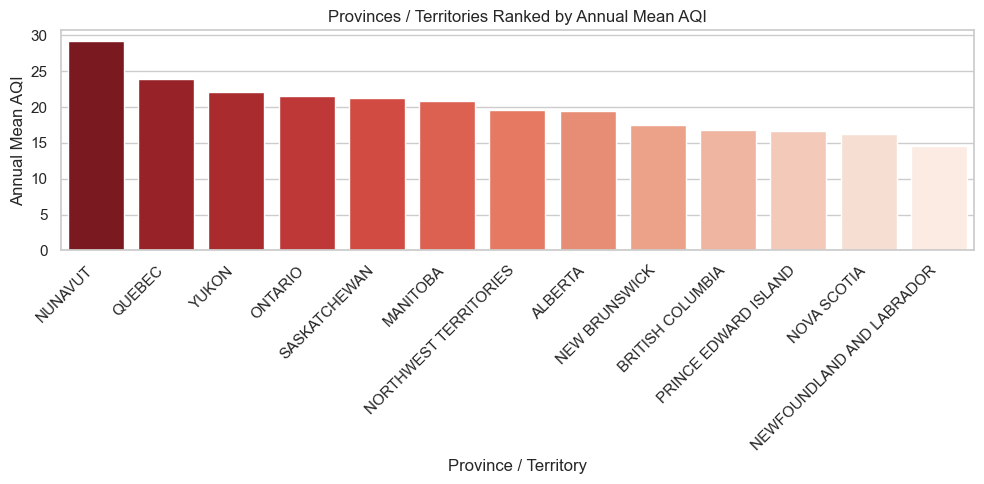

In [91]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=province_rank,
    x="Province/Territory",
    y="annual_mean_AQI",
    palette="Reds_r"
)

plt.title("Provinces / Territories Ranked by Annual Mean AQI")
plt.xlabel("Province / Territory")
plt.ylabel("Annual Mean AQI")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 1️⃣ Ranking chart: Which province has higher AQI overall?

✅ Horizontal bar chart (BEST for ranking)

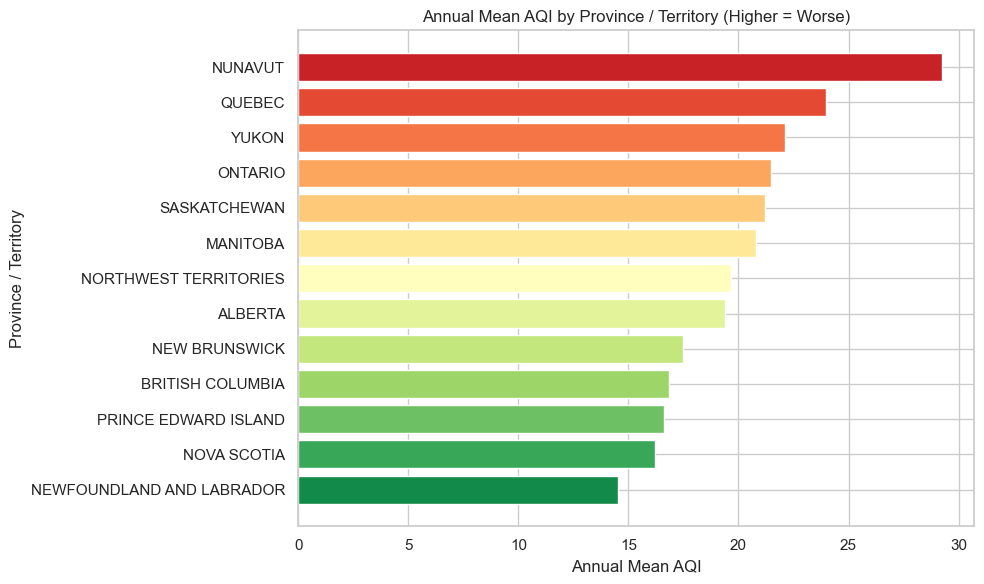

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns

province_rank_sorted = province_rank.sort_values("annual_mean_AQI")


palette = sns.color_palette(
    "RdYlGn_r",      # green → yellow → red
    n_colors=len(province_rank_sorted)
)

plt.figure(figsize=(10, 6))


plt.barh(
    province_rank_sorted["Province/Territory"],
    province_rank_sorted["annual_mean_AQI"],
    color=palette
)

plt.title("Annual Mean AQI by Province / Territory (Higher = Worse)")
plt.xlabel("Annual Mean AQI")
plt.ylabel("Province / Territory")
plt.tight_layout()
plt.show()


## 2️⃣ Frequency vs severity: Are problems frequent or extreme?
This plot shows how provinces differ in risk style.
✅ Bubble chart (advanced but very informative)

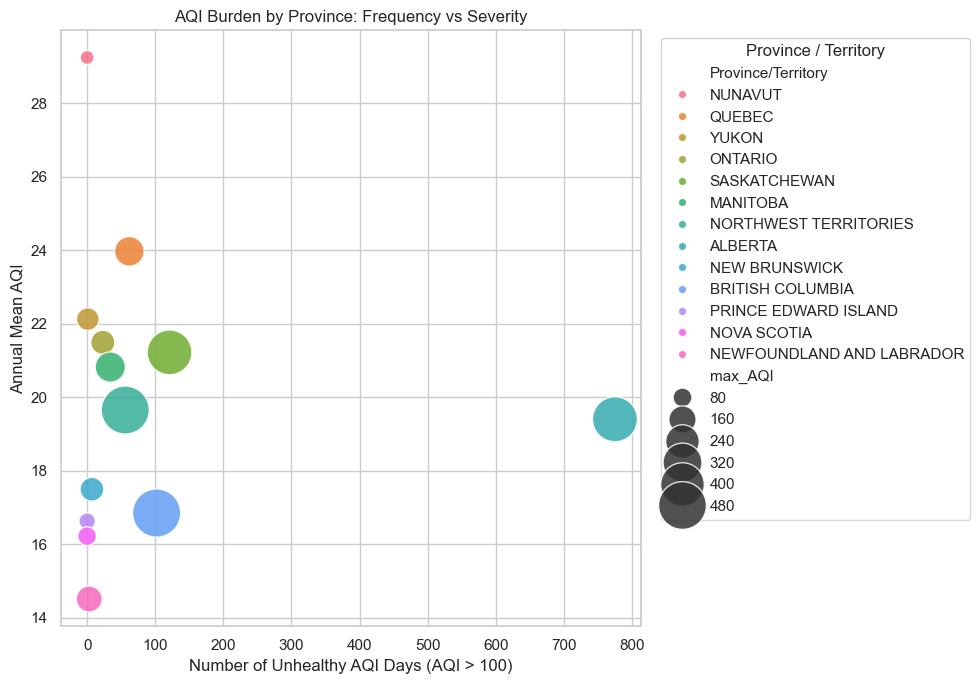

In [94]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=province_rank,
    x="unhealthy_days",
    y="annual_mean_AQI",
    size="max_AQI",
    sizes=(100, 1200),
    hue="Province/Territory",
    alpha=0.85
)

plt.title("AQI Burden by Province: Frequency vs Severity")
plt.xlabel("Number of Unhealthy AQI Days (AQI > 100)")
plt.ylabel("Annual Mean AQI")
plt.legend(
    title="Province / Territory",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

## 3️⃣ Heatmap‑style comparison: Which provinces are consistently worse?
This compresses all information into one visual.
✅ Normalize metrics and show comparison


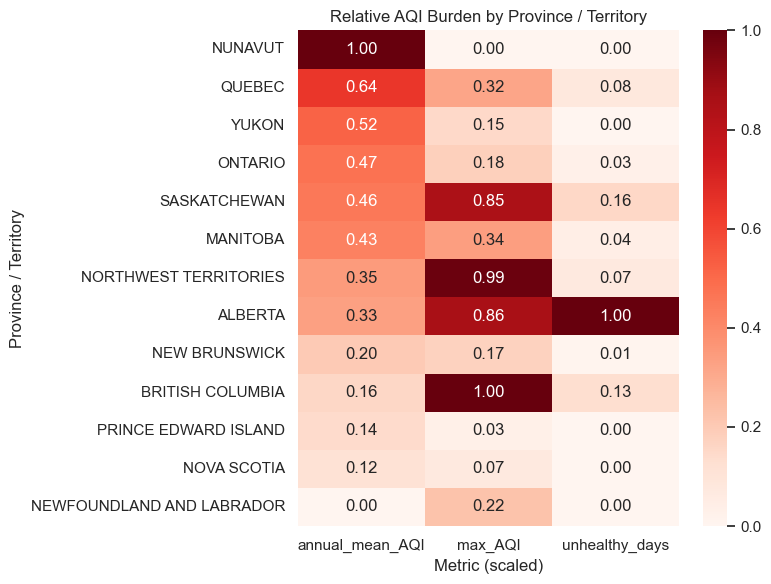

In [95]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

metrics = province_rank.set_index("Province/Territory")[[
    "annual_mean_AQI", "max_AQI", "unhealthy_days"
]]

scaler = MinMaxScaler()
metrics_scaled = pd.DataFrame(
    scaler.fit_transform(metrics),
    index=metrics.index,
    columns=metrics.columns
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    metrics_scaled,
    cmap="Reds",
    annot=True,
    fmt=".2f"
)

plt.title("Relative AQI Burden by Province / Territory")
plt.xlabel("Metric (scaled)")
plt.ylabel("Province / Territory")
plt.tight_layout()
plt.show()